In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
from sklearn.preprocessing import StandardScaler

data = pd.read_csv('bank_data.csv')

columns_to_use = ['BALANCE_FREQUENCY', 'PURCHASES_FREQUENCY', 'PURCHASES_TRX', 'PURCHASES']
X = data[columns_to_use]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

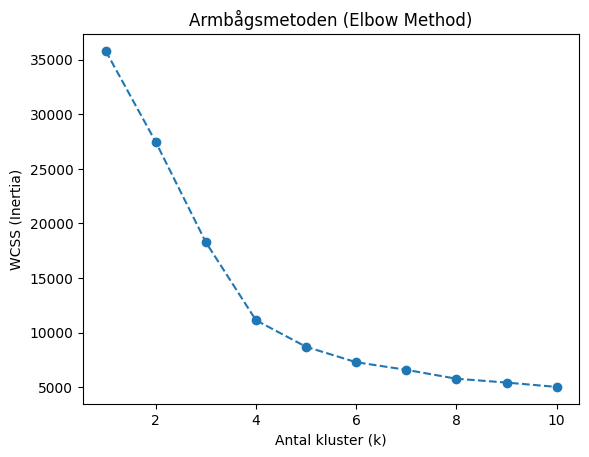

In [7]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Vi skapar en lista för att spara alla "tröghetsvärden" (inertia)
wcss = [] 

# Vi testar k-värden från 1 till 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Nu ritar vi diagrammet! 📊
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Armbågsmetoden (Elbow Method)')
plt.xlabel('Antal kluster (k)')
plt.ylabel('WCSS (Inertia)')
plt.show()

In [8]:
# Vi skapar modellen med 3 kluster (baserat på din armbåge!)
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)

# Vi låter modellen lära sig av den skalade datan och sparar resultatet
y_kmeans = kmeans.fit_predict(X_scaled)

# Vi lägger tillbaka resultatet i vår ursprungliga tabell så vi kan se vem som är vem
data['Cluster'] = y_kmeans

# Nu kan vi titta på de första raderna och se den nya kolumnen 'Cluster'
print(data[['CUST_ID', 'Cluster']].head())

  CUST_ID  Cluster
0  C10001        0
1  C10002        0
2  C10003        0
3  C10004        1
4  C10005        0


In [11]:
# Vi påminner Python om vilka kolumner vi vill titta närmare på
columns = ['BALANCE_FREQUENCY', 'PURCHASES_FREQUENCY', 'PURCHASES_TRX', 'PURCHASES']

# Nu kan vi gruppera kunderna och se medelvärdet för varje kluster!
cluster_analysis = data.groupby('Cluster')[columns].mean()

cluster_analysis

,BALANCE_FREQUENCY,PURCHASES_FREQUENCY,PURCHASES_TRX,PURCHASES
Cluster,,,,
0,0.970180,0.461855,8.790505,550.572772
1,0.396700,0.267535,4.329499,334.835744
2,0.984918,0.959321,63.443119,4559.670275


/Users/matildakosir/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128717 (\N{SHOPPING BAGS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/matildakosir/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/matildakosir/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


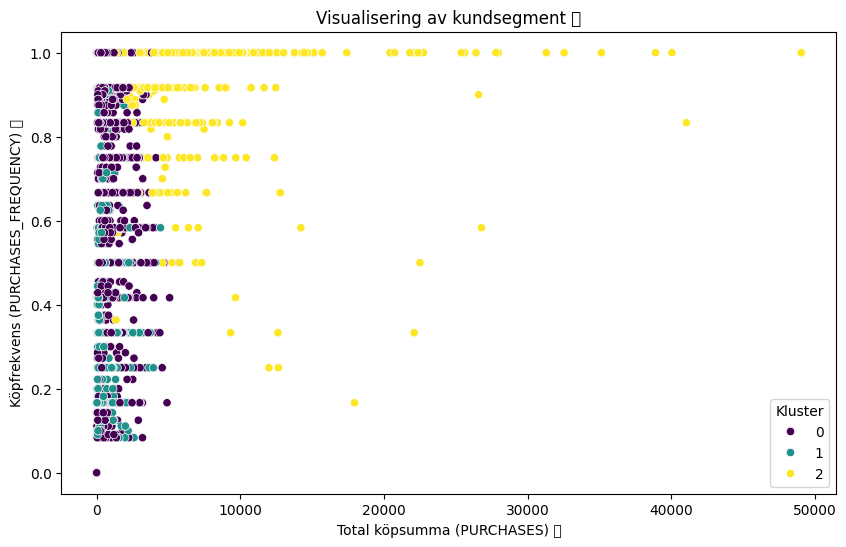

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vi skapar ett diagram som visar Sambandet mellan köp och frekvens
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='PURCHASES', y='PURCHASES_FREQUENCY', hue='Cluster', palette='viridis')

plt.title('Visualisering av kundsegment 📊')
plt.xlabel('Total köpsumma (PURCHASES) 💰')
plt.ylabel('Köpfrekvens (PURCHASES_FREQUENCY) 🛍️')
plt.legend(title='Kluster')
plt.show()

/Users/matildakosir/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


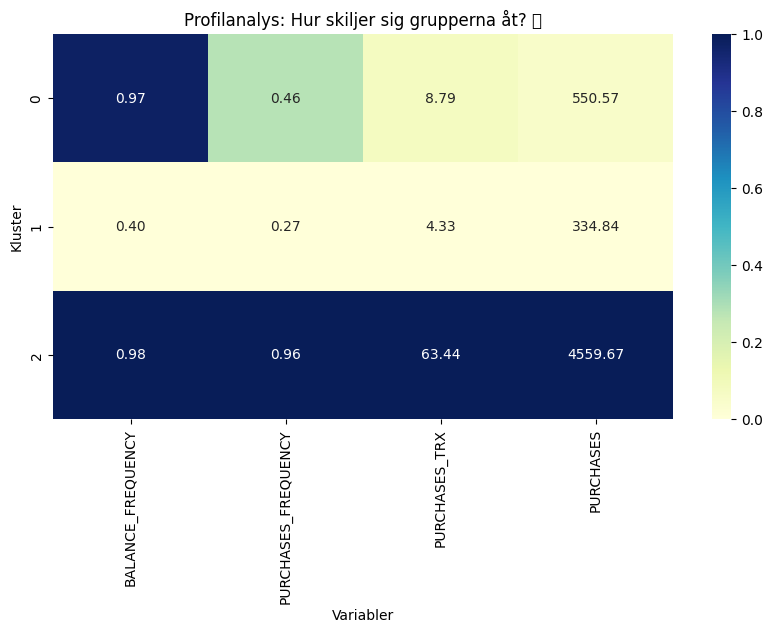

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Vi använder medelvärdena vi räknade ut tidigare
# 2. Vi normaliserar värdena (0-1) för att kunna jämföra dem i samma färgskala
cluster_profiles = cluster_analysis.apply(lambda x: (x - x.min()) / (x.max() - x.min()))

# 3. Vi ritar värmekartan
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profiles, annot=cluster_analysis, fmt=".2f", cmap='YlGnBu')

plt.title('Profilanalys: Hur skiljer sig grupperna åt? 🌡️')
plt.ylabel('Kluster')
plt.xlabel('Variabler')
plt.show()

/var/folders/bh/166ml5hd70z9s6n98yg22k440000gn/T/ipykernel_25599/294072471.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i//2, i%2], data=data, x='Cluster', y=col, palette='Set2')
/var/folders/bh/166ml5hd70z9s6n98yg22k440000gn/T/ipykernel_25599/294072471.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i//2, i%2], data=data, x='Cluster', y=col, palette='Set2')
/var/folders/bh/166ml5hd70z9s6n98yg22k440000gn/T/ipykernel_25599/294072471.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i//2, i%2], data=data, x

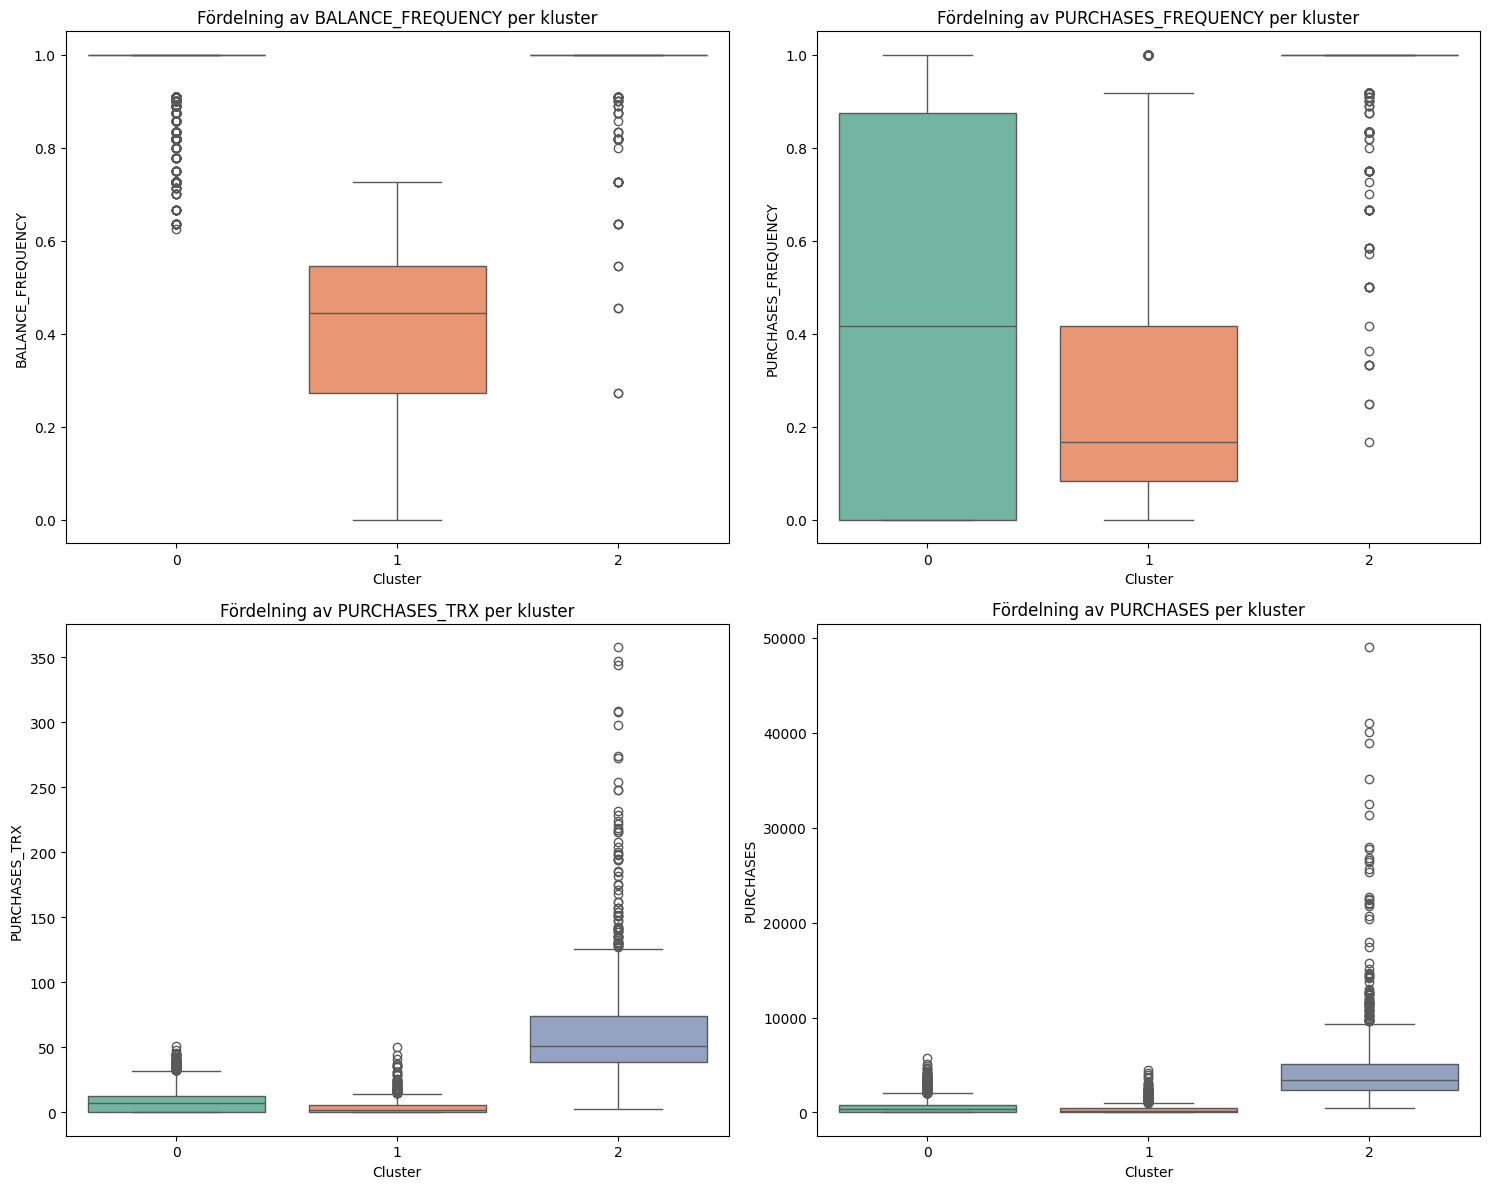

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Vi ser till att vi använder rätt variabelnamn (data istället för df)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for i, col in enumerate(columns):
    # Här ändrade vi till data=data
    sns.boxplot(ax=axes[i//2, i%2], data=data, x='Cluster', y=col, palette='Set2')
    axes[i//2, i%2].set_title(f'Fördelning av {col} per kluster')

plt.tight_layout()
plt.show()

/Users/matildakosir/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128717 (\N{SHOPPING BAGS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/matildakosir/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128179 (\N{CREDIT CARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/matildakosir/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


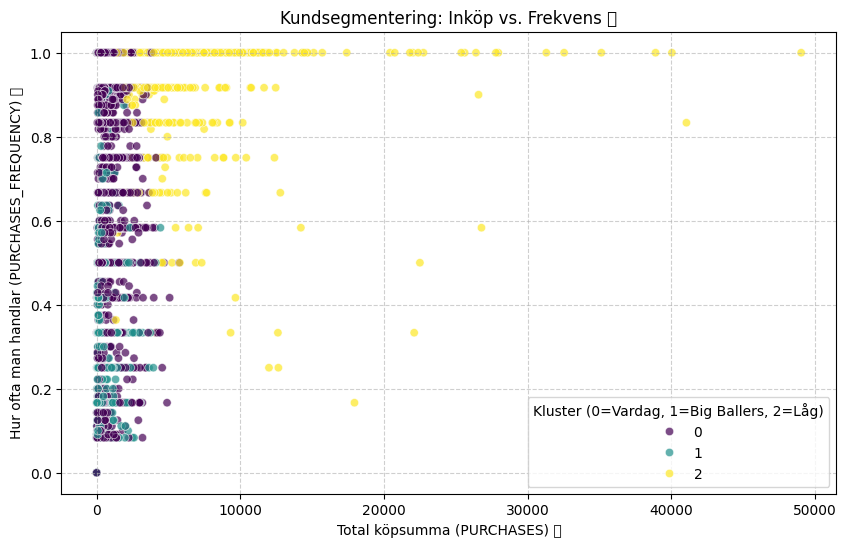

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Vi skapar en scatterplot för att visualisera våra kluster
plt.figure(figsize=(10, 6))

# Vi väljer 'PURCHASES' på x-axeln och 'PURCHASES_FREQUENCY' på y-axeln
# 'hue' gör att vi färglägger punkterna baserat på vilket kluster de tillhör
sns.scatterplot(data=data, x='PURCHASES', y='PURCHASES_FREQUENCY', hue='Cluster', palette='viridis', alpha=0.7)

plt.title('Kundsegmentering: Inköp vs. Frekvens 💳')
plt.xlabel('Total köpsumma (PURCHASES) 💰')
plt.ylabel('Hur ofta man handlar (PURCHASES_FREQUENCY) 🛍️')
plt.legend(title='Kluster (0=Vardag, 1=Big Ballers, 2=Låg)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

/Users/matildakosir/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


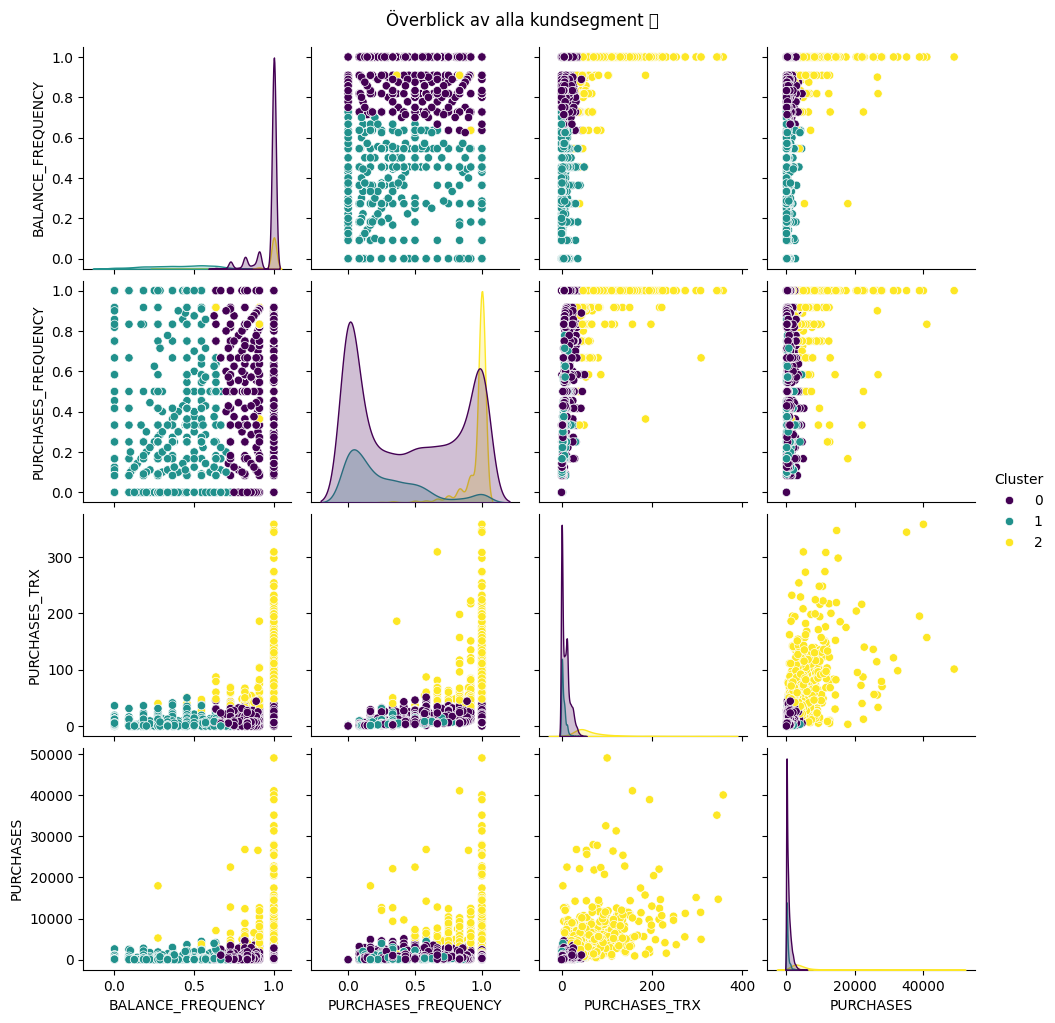

In [17]:
# Vi skapar ett rutnät av diagram för alla våra variabler
sns.pairplot(data=data, vars=columns, hue='Cluster', palette='viridis', diag_kind='kde')
plt.suptitle('Överblick av alla kundsegment 🌐', y=1.02)
plt.show()

/Users/matildakosir/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127756 (\N{MILKY WAY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


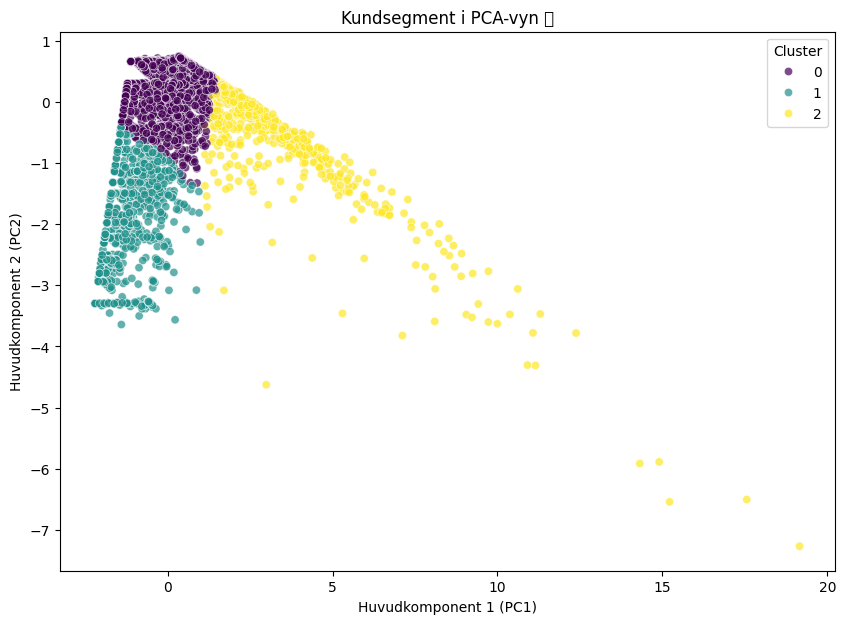

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Vi skapar en PCA-modell som ska hitta 2 huvudkomponenter
pca = PCA(n_components=2)

# 2. Vi kör PCA på vår skalade data
pca_result = pca.fit_transform(X_scaled)

# 3. Vi sparar resultaten i vår tabell
data['PC1'] = pca_result[:, 0]
data['PC2'] = pca_result[:, 1]

# 4. Vi ritar upp resultatet!
plt.figure(figsize=(10, 7))
sns.scatterplot(data=data, x='PC1', y='PC2', hue='Cluster', palette='viridis', alpha=0.7)

plt.title('Kundsegment i PCA-vyn 🌌')
plt.xlabel('Huvudkomponent 1 (PC1)')
plt.ylabel('Huvudkomponent 2 (PC2)')
plt.show()